# Predictive Maintenance for Vehicles

## Machine Learning Based Vehicle Failure Prediction and Maintenance Analytics

# 1.Import libraries for data analysis and visualization

In [58]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 2.Load Dataset

In [59]:
# Load the vehicle maintenance dataset

vehicle_data = pd.read_csv("synthetic_telemetry_data.csv")

vehicle_data.head()

,vehicle_id,brand,timestamp,odometer_reading,engine_temp_c,engine_rpm,oil_pressure_psi,coolant_temp_c,fuel_level_percent,fuel_consumption_lph,...,vehicle_speed_kph,ambient_temp_c,humidity_percent,gps_latitude,gps_longitude,engine_failure_imminent,brake_issue_imminent,battery_issue_imminent,failure_date,failure_type
0,VEH0000,BMW,2023-01-01 00:00:00,31381.561743,99.388213,2212.155243,55.522505,91.788105,68.368162,4.076315,...,116.501239,24.187057,83.785796,31.986296,78.203395,0,0,0,2050-01-01 00:00:00,No Failure
1,VEH0000,BMW,2023-01-01 00:56:00,31391.284155,84.118706,961.795251,57.799346,87.283282,99.064394,7.059168,...,39.409933,15.148875,57.418501,30.620539,84.389727,0,0,0,2050-01-01 00:00:00,No Failure
2,VEH0000,BMW,2023-01-01 01:28:00,31428.088015,103.521431,742.050437,50.398848,83.503155,80.280244,10.792362,...,82.077798,23.138714,80.540135,30.634997,79.039234,0,0,0,2050-01-01 00:00:00,No Failure
3,VEH0000,BMW,2023-01-01 01:27:00,31463.271669,91.130527,2723.042461,41.719715,90.997963,13.892586,1.564630,...,70.294428,35.058947,57.221563,33.490971,76.107248,0,0,0,2050-01-01 00:00:00,No Failure
4,VEH0000,BMW,2023-01-01 01:00:00,31490.411858,96.887263,2647.979969,38.438964,93.029011,20.871931,6.814662,...,74.028392,18.024207,47.680115,28.392300,83.160007,0,0,0,2050-01-01 00:00:00,No Failure


# 3.data Understanding

In [60]:
# Check the number of rows and columns in the dataset

vehicle_data.shape

(1970, 41)

In [61]:
# View all column names in the dataset

vehicle_data.columns

Index(['vehicle_id', 'brand', 'timestamp', 'odometer_reading', 'engine_temp_c',
       'engine_rpm', 'oil_pressure_psi', 'coolant_temp_c',
       'fuel_level_percent', 'fuel_consumption_lph', 'engine_load_percent',
       'throttle_pos_percent', 'air_flow_rate_gps', 'exhaust_gas_temp_c',
       'vibration_level', 'engine_hours', 'brake_fluid_level_psi',
       'brake_pad_wear_mm', 'brake_temp_c', 'abs_fault_indicator',
       'brake_pedal_pos_percent', 'wheel_speed_fl_kph', 'wheel_speed_fr_kph',
       'wheel_speed_rl_kph', 'wheel_speed_rr_kph', 'battery_voltage_v',
       'battery_current_a', 'battery_temp_c', 'alternator_output_v',
       'battery_charge_percent', 'battery_health_percent', 'vehicle_speed_kph',
       'ambient_temp_c', 'humidity_percent', 'gps_latitude', 'gps_longitude',
       'engine_failure_imminent', 'brake_issue_imminent',
       'battery_issue_imminent', 'failure_date', 'failure_type'],
      dtype='object')

In [62]:
# Check column data types and non-null values

vehicle_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1970 entries, 0 to 1969
Data columns (total 41 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   vehicle_id               1970 non-null   object 
 1   brand                    1970 non-null   object 
 2   timestamp                1970 non-null   object 
 3   odometer_reading         1970 non-null   float64
 4   engine_temp_c            1970 non-null   float64
 5   engine_rpm               1970 non-null   float64
 6   oil_pressure_psi         1970 non-null   float64
 7   coolant_temp_c           1970 non-null   float64
 8   fuel_level_percent       1970 non-null   float64
 9   fuel_consumption_lph     1970 non-null   float64
 10  engine_load_percent      1970 non-null   float64
 11  throttle_pos_percent     1970 non-null   float64
 12  air_flow_rate_gps        1970 non-null   float64
 13  exhaust_gas_temp_c       1970 non-null   float64
 14  vibration_level         

In [63]:
# Check missing values in each column

vehicle_data.isnull().sum()

vehicle_id                 0
brand                      0
timestamp                  0
odometer_reading           0
engine_temp_c              0
engine_rpm                 0
oil_pressure_psi           0
coolant_temp_c             0
fuel_level_percent         0
fuel_consumption_lph       0
engine_load_percent        0
throttle_pos_percent       0
air_flow_rate_gps          0
exhaust_gas_temp_c         0
vibration_level            0
engine_hours               0
brake_fluid_level_psi      0
brake_pad_wear_mm          0
brake_temp_c               0
abs_fault_indicator        0
brake_pedal_pos_percent    0
wheel_speed_fl_kph         0
wheel_speed_fr_kph         0
wheel_speed_rl_kph         0
wheel_speed_rr_kph         0
battery_voltage_v          0
battery_current_a          0
battery_temp_c             0
alternator_output_v        0
battery_charge_percent     0
battery_health_percent     0
vehicle_speed_kph          0
ambient_temp_c             0
humidity_percent           0
gps_latitude  

# 4.Data Cleaning

In [64]:
# Check duplicate records

vehicle_data.duplicated().sum()

np.int64(0)

In [65]:
# Convert date columns into datetime format

vehicle_data["timestamp"] = pd.to_datetime(vehicle_data["timestamp"])
vehicle_data["failure_date"] = pd.to_datetime(vehicle_data["failure_date"])

vehicle_data[["timestamp", "failure_date"]].dtypes

timestamp       datetime64[ns]
failure_date    datetime64[ns]
dtype: object

In [66]:
# Check vehicle failure target values

print(vehicle_data["engine_failure_imminent"].value_counts())
print(vehicle_data["brake_issue_imminent"].value_counts())
print(vehicle_data["battery_issue_imminent"].value_counts())

engine_failure_imminent
0    1963
1       7
Name: count, dtype: int64
brake_issue_imminent
0    1954
1      16
Name: count, dtype: int64
battery_issue_imminent
0    1958
1      12
Name: count, dtype: int64


# 5. Exploratory Data Analysis (EDA)

In [67]:
# Check the number of vehicles for each failure type

vehicle_data["failure_type"].value_counts()

failure_type
No Failure             1935
Brake Pad Worn            9
Low Brake Fluid           5
Battery Dead              4
Engine Overheat           4
Battery Drain             4
Low Battery Voltage       4
Excessive Vibration       2
Brake Overheat            2
Low Oil Pressure          1
Name: count, dtype: int64

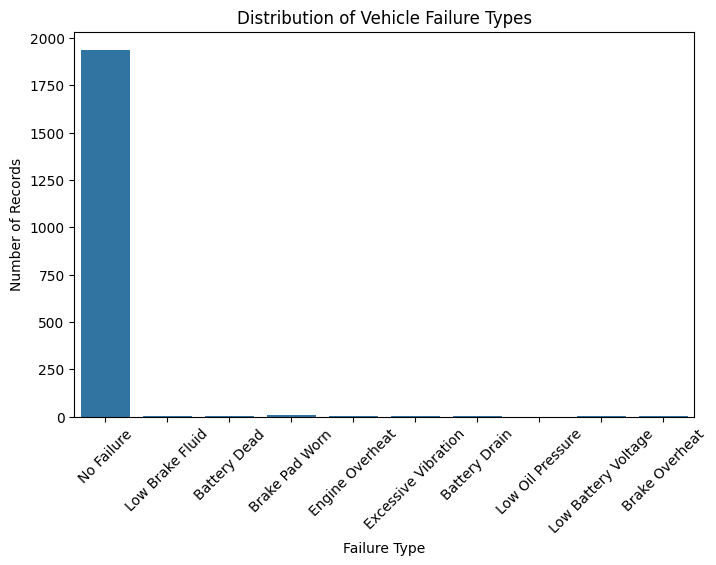

In [68]:
# Visualize failure type distribution

plt.figure(figsize=(8, 5))
sns.countplot(data=vehicle_data, x="failure_type")

plt.title("Distribution of Vehicle Failure Types")
plt.xlabel("Failure Type")
plt.ylabel("Number of Records")
plt.xticks(rotation=45)
plt.show()

In [69]:
# Compare engine temperature for normal and imminent engine failure cases

vehicle_data.groupby("engine_failure_imminent")[
    ["engine_temp_c", "engine_rpm", "oil_pressure_psi", "vibration_level"]
].mean()

,engine_temp_c,engine_rpm,oil_pressure_psi,vibration_level
engine_failure_imminent,,,,
0,95.042261,2013.417580,44.831836,1.497962
1,110.780986,1462.848907,9.383802,5.527972


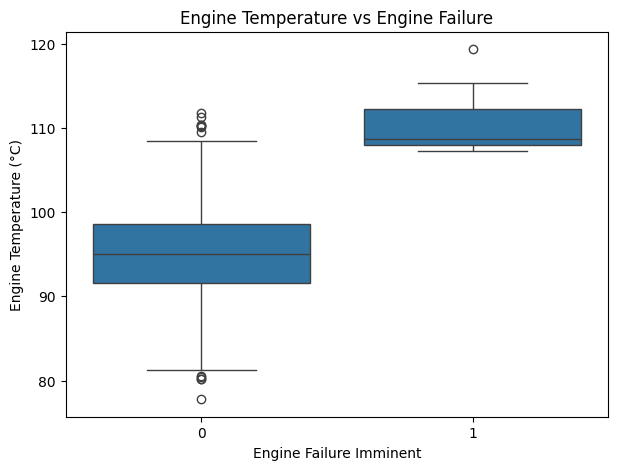

In [70]:
# Visualize engine temperature by engine failure status

plt.figure(figsize=(7, 5))
sns.boxplot(
    data=vehicle_data,
    x="engine_failure_imminent",
    y="engine_temp_c"
)

plt.title("Engine Temperature vs Engine Failure")
plt.xlabel("Engine Failure Imminent")
plt.ylabel("Engine Temperature (°C)")
plt.show()

In [71]:
# Compare brake conditions for normal and imminent brake issue cases

vehicle_data.groupby("brake_issue_imminent")[
    ["brake_fluid_level_psi", "brake_pad_wear_mm", "brake_temp_c"]
].mean()

,brake_fluid_level_psi,brake_pad_wear_mm,brake_temp_c
brake_issue_imminent,,,
0,1001.123356,8.068045,79.641991
1,555.904305,8.440321,321.769313


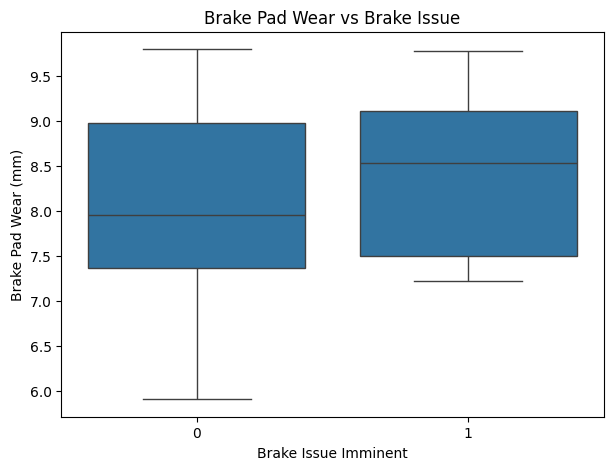

In [72]:
# Visualize brake pad wear by brake issue status

plt.figure(figsize=(7, 5))
sns.boxplot(
    data=vehicle_data,
    x="brake_issue_imminent",
    y="brake_pad_wear_mm"
)

plt.title("Brake Pad Wear vs Brake Issue")
plt.xlabel("Brake Issue Imminent")
plt.ylabel("Brake Pad Wear (mm)")
plt.show()

# 6. Battery & Sensor Analysis

In [73]:
# Compare battery conditions for normal and imminent battery issue cases

vehicle_data.groupby("battery_issue_imminent")[
    ["battery_voltage_v", "battery_temp_c",
     "battery_charge_percent", "battery_health_percent"]
].mean()

,battery_voltage_v,battery_temp_c,battery_charge_percent,battery_health_percent
battery_issue_imminent,,,,
0,12.594499,25.003690,70.080222,94.330723
1,10.026392,25.042883,72.041321,94.049221


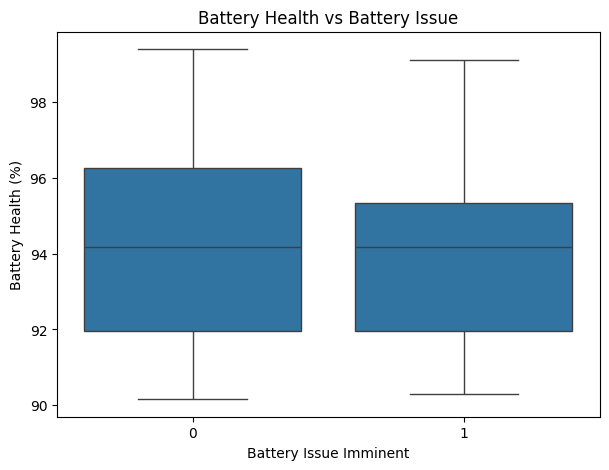

In [74]:
# Visualize battery health by battery issue status

plt.figure(figsize=(7, 5))

sns.boxplot(
    data=vehicle_data,
    x="battery_issue_imminent",
    y="battery_health_percent"
)

plt.title("Battery Health vs Battery Issue")
plt.xlabel("Battery Issue Imminent")
plt.ylabel("Battery Health (%)")

plt.show()

In [75]:
# Check correlation between important vehicle sensor values

sensor_columns = [
    "engine_temp_c",
    "engine_rpm",
    "oil_pressure_psi",
    "vibration_level",
    "brake_pad_wear_mm",
    "brake_temp_c",
    "battery_voltage_v",
    "battery_health_percent",
    "engine_failure_imminent",
    "brake_issue_imminent",
    "battery_issue_imminent"
]

vehicle_data[sensor_columns].corr()

,engine_temp_c,engine_rpm,oil_pressure_psi,vibration_level,brake_pad_wear_mm,brake_temp_c,battery_voltage_v,battery_health_percent,engine_failure_imminent,brake_issue_imminent,battery_issue_imminent
engine_temp_c,1.000000,-0.004348,-0.017588,0.068195,-0.002681,0.017841,0.007747,-0.002637,0.180093,-0.004320,0.001252
engine_rpm,-0.004348,1.000000,-0.022947,-0.036684,-0.029983,-0.041345,-0.010549,-0.008046,-0.043067,0.001508,-0.004026
oil_pressure_psi,-0.017588,-0.022947,1.000000,-0.075634,-0.010226,0.017713,0.007575,-0.016253,-0.208565,0.015958,0.030440
vibration_level,0.068195,-0.036684,-0.075634,1.000000,0.022272,0.017123,0.046903,0.004069,0.431505,0.020130,-0.025509
brake_pad_wear_mm,-0.002681,-0.029983,-0.010226,0.022272,1.000000,0.013537,-0.005623,-0.110713,-0.013066,0.033080,0.023790
brake_temp_c,0.017841,-0.041345,0.017713,0.017123,0.013537,1.000000,-0.004741,0.017841,0.004905,0.398211,0.007565
battery_voltage_v,0.007747,-0.010549,0.007575,0.046903,-0.005623,-0.004741,1.000000,-0.015615,-0.011177,0.035267,-0.375881
battery_health_percent,-0.002637,-0.008046,-0.016253,0.004069,-0.110713,0.017841,-0.015615,1.000000,-0.020854,-0.010739,-0.008621
engine_failure_imminent,0.180093,-0.043067,-0.208565,0.431505,-0.013066,0.004905,-0.011177,-0.020854,1.000000,-0.005404,-0.004675
brake_issue_imminent,-0.004320,0.001508,0.015958,0.020130,0.033080,0.398211,0.035267,-0.010739,-0.005404,1.000000,-0.007084


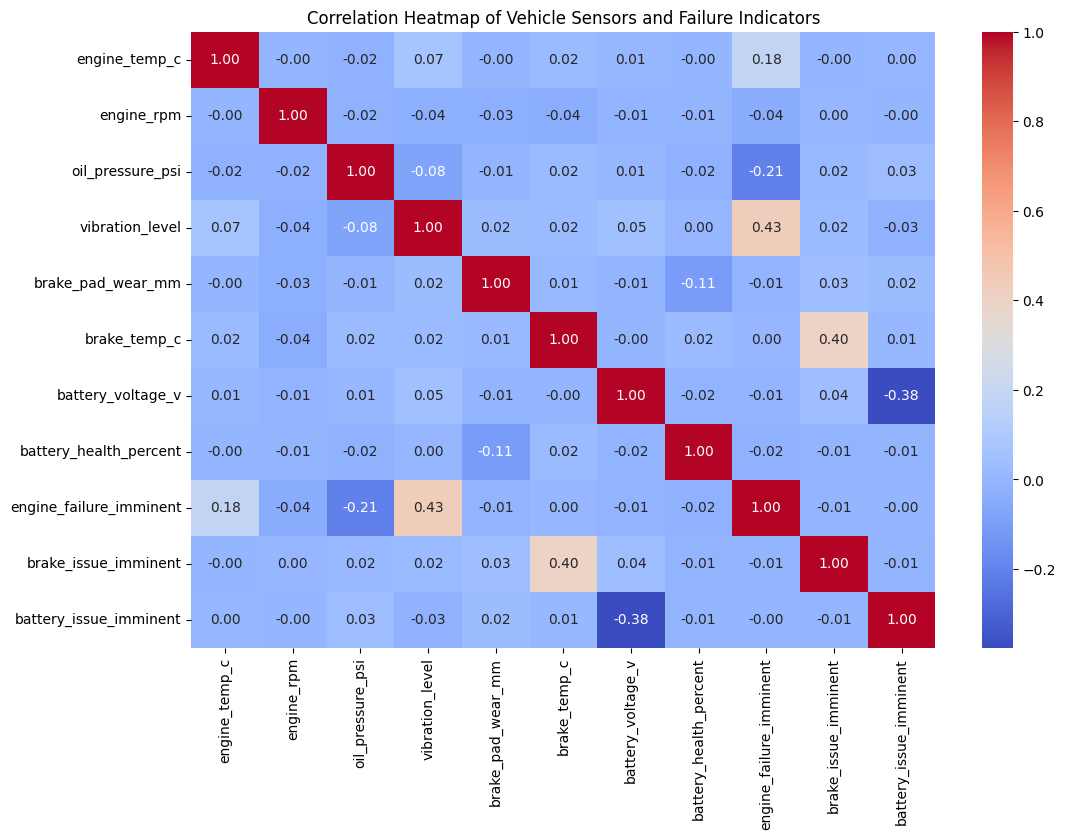

In [76]:
# Visualize correlation between important vehicle sensors and failure indicators

plt.figure(figsize=(12, 8))

correlation_matrix = vehicle_data[sensor_columns].corr()

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

plt.title("Correlation Heatmap of Vehicle Sensors and Failure Indicators")
plt.show()

# 7. Data Preprocessing for Machine Learning

In [77]:
# Create an overall vehicle maintenance target

vehicle_data["maintenance_required"] = (
    (vehicle_data["engine_failure_imminent"] == 1) |
    (vehicle_data["brake_issue_imminent"] == 1) |
    (vehicle_data["battery_issue_imminent"] == 1)
).astype(int)

vehicle_data["maintenance_required"].value_counts()

maintenance_required
0    1935
1      35
Name: count, dtype: int64

In [78]:
# Check maintenance requirement percentage

vehicle_data["maintenance_required"].value_counts(normalize=True) * 100

maintenance_required
0    98.22335
1     1.77665
Name: proportion, dtype: float64

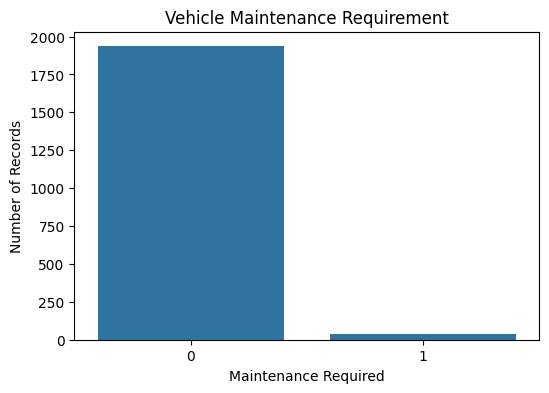

In [79]:
# Visualize maintenance requirement distribution

plt.figure(figsize=(6, 4))

sns.countplot(
    data=vehicle_data,
    x="maintenance_required"
)

plt.title("Vehicle Maintenance Requirement")
plt.xlabel("Maintenance Required")
plt.ylabel("Number of Records")

plt.show()

# 8. Feature Selection & Train-Test Split

In [80]:
# Select important vehicle sensor features for machine learning

features = [
    "odometer_reading",
    "engine_temp_c",
    "engine_rpm",
    "oil_pressure_psi",
    "coolant_temp_c",
    "fuel_consumption_lph",
    "engine_load_percent",
    "vibration_level",
    "engine_hours",
    "brake_fluid_level_psi",
    "brake_pad_wear_mm",
    "brake_temp_c",
    "battery_voltage_v",
    "battery_current_a",
    "battery_temp_c",
    "battery_charge_percent",
    "battery_health_percent",
    "vehicle_speed_kph",
    "ambient_temp_c",
    "humidity_percent"
]

X = vehicle_data[features]
y = vehicle_data["maintenance_required"]

X.head()

,odometer_reading,engine_temp_c,engine_rpm,oil_pressure_psi,coolant_temp_c,fuel_consumption_lph,engine_load_percent,vibration_level,engine_hours,brake_fluid_level_psi,brake_pad_wear_mm,brake_temp_c,battery_voltage_v,battery_current_a,battery_temp_c,battery_charge_percent,battery_health_percent,vehicle_speed_kph,ambient_temp_c,humidity_percent
0,31381.561743,99.388213,2212.155243,55.522505,91.788105,4.076315,93.475782,1.246835,1090.660799,948.049061,7.751081,209.715927,11.772458,-56.677920,28.472226,62.572507,90.828792,116.501239,24.187057,83.785796
1,31391.284155,84.118706,961.795251,57.799346,87.283282,7.059168,77.434090,1.918611,1090.869529,1159.397764,7.745846,99.574128,12.286638,-26.111756,25.799318,83.556121,90.826238,39.409933,15.148875,57.418501
2,31428.088015,103.521431,742.050437,50.398848,83.503155,10.792362,52.634815,1.286237,1091.245803,1094.282610,7.738505,99.992320,12.405697,25.597456,28.847737,49.472221,90.821462,82.077798,23.138714,80.540135
3,31463.271669,91.130527,2723.042461,41.719715,90.997963,1.564630,69.316754,1.891411,1091.455085,1021.804303,7.729657,26.430565,12.622920,51.582360,29.472934,60.216699,90.819427,70.294428,35.058947,57.221563
4,31490.411858,96.887263,2647.979969,38.438964,93.029011,6.814662,45.953809,2.080484,1091.620959,971.627513,7.727314,13.520961,13.198959,22.585027,24.251833,73.706776,90.814681,74.028392,18.024207,47.680115


In [81]:
# Split the dataset into training and testing data

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (1576, 20)
X_test : (394, 20)
y_train: (1576,)
y_test : (394,)


In [82]:
# Check maintenance target distribution in training data

y_train.value_counts(normalize=True) * 100

maintenance_required
0    98.22335
1     1.77665
Name: proportion, dtype: float64

# 9. Machine Learning Model Building

In [83]:
# Import machine learning models and evaluation metrics

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

In [85]:
# Scale features for Logistic Regression

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [86]:
# Train Logistic Regression model using scaled data

logistic_model = LogisticRegression(
    max_iter=1000,
    class_weight="balanced",
    random_state=42
)

logistic_model.fit(X_train_scaled, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,random_state,42
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [88]:
logistic_predictions = logistic_model.predict(X_test_scaled)
logistic_predictions

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0,
       0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,

In [89]:
# Evaluate Logistic Regression model

print("Accuracy :", accuracy_score(y_test, logistic_predictions))
print("Precision:", precision_score(y_test, logistic_predictions))
print("Recall   :", recall_score(y_test, logistic_predictions))
print("F1 Score :", f1_score(y_test, logistic_predictions))

print("\nClassification Report:")
print(classification_report(y_test, logistic_predictions))

Accuracy : 0.9873096446700508
Precision: 0.6
Recall   : 0.8571428571428571
F1 Score : 0.7058823529411765

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.99      0.99       387
           1       0.60      0.86      0.71         7

    accuracy                           0.99       394
   macro avg       0.80      0.92      0.85       394
weighted avg       0.99      0.99      0.99       394



In [90]:
# Train Decision Tree model

decision_tree_model = DecisionTreeClassifier(
    class_weight="balanced",
    random_state=42
)

decision_tree_model.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,'balanced'


In [91]:
decision_tree_predictions = decision_tree_model.predict(X_test)
decision_tree_predictions

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0,
       0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,

In [92]:
# Evaluate Decision Tree model

print("Accuracy :", accuracy_score(y_test, decision_tree_predictions))
print("Precision:", precision_score(y_test, decision_tree_predictions))
print("Recall   :", recall_score(y_test, decision_tree_predictions))
print("F1 Score :", f1_score(y_test, decision_tree_predictions))

Accuracy : 0.9949238578680203
Precision: 0.8571428571428571
Recall   : 0.8571428571428571
F1 Score : 0.8571428571428571


In [93]:
# Train Random Forest model

random_forest_model = RandomForestClassifier(
    n_estimators=100,
    class_weight="balanced",
    random_state=42
)

random_forest_model.fit(X_train, y_train)


,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [96]:
random_forest_predictions = random_forest_model.predict(X_test)
random_forest_predictions

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,

In [97]:
# Evaluate Random Forest model

print("Accuracy :", accuracy_score(y_test, random_forest_predictions))
print("Precision:", precision_score(y_test, random_forest_predictions))
print("Recall   :", recall_score(y_test, random_forest_predictions))
print("F1 Score :", f1_score(y_test, random_forest_predictions))

Accuracy : 0.9949238578680203
Precision: 1.0
Recall   : 0.7142857142857143
F1 Score : 0.8333333333333334


# 10. Model Comparison & Best Model Selection

In [99]:
# Compare performance of all machine learning models

model_results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest"
    ],
    "Accuracy": [
        accuracy_score(y_test, logistic_predictions),
        accuracy_score(y_test, decision_tree_predictions),
        accuracy_score(y_test, random_forest_predictions)
    ],
    "Precision": [
        precision_score(y_test, logistic_predictions),
        precision_score(y_test, decision_tree_predictions),
        precision_score(y_test, random_forest_predictions)
    ],
    "Recall": [
        recall_score(y_test, logistic_predictions),
        recall_score(y_test, decision_tree_predictions),
        recall_score(y_test, random_forest_predictions)
    ],
    "F1 Score": [
        f1_score(y_test, logistic_predictions),
        f1_score(y_test, decision_tree_predictions),
        f1_score(y_test, random_forest_predictions)
    ]
})

model_results

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.987310,0.600000,0.857143,0.705882
1,Decision Tree,0.994924,0.857143,0.857143,0.857143
2,Random Forest,0.994924,1.000000,0.714286,0.833333


In [100]:
# Select the best model based on F1 Score

best_model_name = model_results.loc[
    model_results["F1 Score"].idxmax(),
    "Model"
]

print("Best Model:", best_model_name)

Best Model: Decision Tree


In [101]:
# Store the selected best model for further predictions

if best_model_name == "Logistic Regression":
    best_model = logistic_model
    best_predictions = logistic_predictions

elif best_model_name == "Decision Tree":
    best_model = decision_tree_model
    best_predictions = decision_tree_predictions

else:
    best_model = random_forest_model
    best_predictions = random_forest_predictions

# 11. Best Model Evaluation

In [102]:
# Display detailed performance of the best model

print("Best Model:", best_model_name)

print("\nClassification Report:")
print(classification_report(y_test, best_predictions))

Best Model: Decision Tree

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       387
           1       0.86      0.86      0.86         7

    accuracy                           0.99       394
   macro avg       0.93      0.93      0.93       394
weighted avg       0.99      0.99      0.99       394



In [103]:
# Create confusion matrix for the best model

conf_matrix = confusion_matrix(y_test, best_predictions)

conf_matrix

array([[386,   1],
       [  1,   6]])

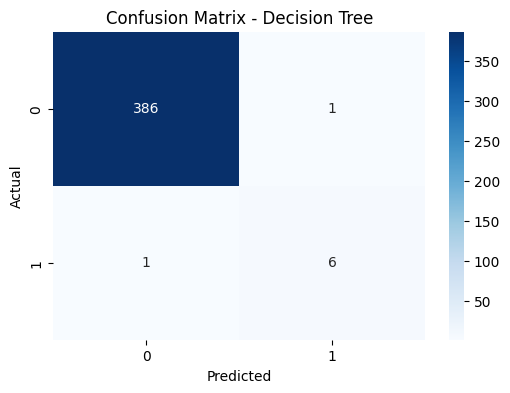

In [104]:
# Visualize the confusion matrix

plt.figure(figsize=(6, 4))

sns.heatmap(
    conf_matrix,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Confusion Matrix - " + best_model_name)
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

# 12. Final Prediction & Export

In [105]:
# Create final prediction results

maintenance_results = vehicle_data.loc[X_test.index].copy()

maintenance_results["Predicted_Maintenance"] = best_predictions

maintenance_results.head()

,vehicle_id,brand,timestamp,odometer_reading,engine_temp_c,engine_rpm,oil_pressure_psi,coolant_temp_c,fuel_level_percent,fuel_consumption_lph,...,humidity_percent,gps_latitude,gps_longitude,engine_failure_imminent,brake_issue_imminent,battery_issue_imminent,failure_date,failure_type,maintenance_required,Predicted_Maintenance
121,VEH0003,Mercedes-Benz,2023-01-01 00:54:00,45231.440679,103.689614,2149.989710,43.789105,91.823546,0.750632,3.342801,...,80.858028,28.781449,78.634341,0,0,0,2050-01-01,No Failure,0,0
807,VEH0020,Audi,2023-01-01 13:48:00,98512.786232,99.212484,2086.577372,31.972235,91.207149,81.849773,8.122015,...,70.131054,30.366414,78.243606,0,0,0,2050-01-01,No Failure,0,0
383,VEH0009,Kia,2023-01-01 18:42:00,81210.853149,97.676972,2288.111185,45.039603,92.899343,81.345277,8.100705,...,41.489888,28.450848,82.014037,0,0,0,2050-01-01,No Failure,0,0
152,VEH0003,Mercedes-Benz,2023-01-01 23:14:00,46002.590483,89.491037,776.106348,44.873435,91.328789,76.513904,1.328332,...,66.913434,29.258863,77.882793,0,0,0,2050-01-01,No Failure,0,0
1076,VEH0027,Mercedes-Benz,2023-01-01 20:54:00,87809.613376,105.725132,1841.056199,49.510188,88.666073,35.758744,5.814802,...,61.626603,32.922219,80.408073,0,0,0,2050-01-01,No Failure,0,0


In [106]:
# Export prediction results for Power BI

maintenance_results.to_csv(
    "vehicle_maintenance_results.csv",
    index=False
)